##Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Activity 1

Read in dataset on AWS at [Brazilian-fire-dataset.csv]( https://ddc-datascience.s3.amazonaws.com/Brazilian-fire-dataset.csv ) and assign to variable `df_ffire`


In [2]:
df_ffire = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Brazilian-fire-dataset.csv')

Display top 10 rows of DataFrame

In [3]:
df_ffire.head(10)

,Year,State,Month,Number of Fires,Date Reported
0,1998,Acre,January,0.0,1/01/1998
1,1999,Acre,January,0.0,1/01/1999
2,2000,Acre,January,0.0,1/01/2000
3,2001,Acre,January,0.0,1/01/2001
4,2002,Acre,January,0.0,1/01/2002
5,2003,Acre,January,10.0,1/01/2003
6,2004,Acre,January,0.0,1/01/2004
7,2005,Acre,January,12.0,1/01/2005
8,2006,Acre,January,4.0,1/01/2006
9,2007,Acre,January,0.0,1/01/2007


Generate summary statistics

In [4]:
df_ffire.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Year,6454.0,2007.461729,5.746654,1998.0,2002.0,2007.0,2012.0,2017.0
Number of Fires,6454.0,108.293163,190.812242,0.0,3.0,24.0,113.0,998.0


##Answer

What is the maximum number of fires reported on any given day?

In [5]:
max = df_ffire['Number of Fires'].max()

print(f'There are {max:.0f} fires reported on any given day.')

There are 998 fires reported on any given day.


In the dataset, what is the total number of states for which the fire incidents have been reported?

In [6]:
total = df_ffire['State'].nunique()

print(f'{total} states had fire incidents that were reported.')

27 states had fire incidents that were reported.


#Activity 2


Change `Date Reported` column to a datetime object


In [7]:
df_ffire['Date Reported'] = pd.to_datetime(df_ffire['Date Reported'])
print(df_ffire['Date Reported'].dtype)

datetime64[ns]


Filter `df_ffire` to only keep rows  in Acre, Bahia or Mato Grosso states and save as `df_ffire_filt`


In [8]:
df_ffire_filt = df_ffire[
  df_ffire['State'].isin(['Acre', 'Bahia', 'Mato Grosso'])
]

df_ffire_filt.head()

,Year,State,Month,Number of Fires,Date Reported
0,1998,Acre,January,0.0,1998-01-01
1,1999,Acre,January,0.0,1999-01-01
2,2000,Acre,January,0.0,2000-01-01
3,2001,Acre,January,0.0,2001-01-01
4,2002,Acre,January,0.0,2002-01-01


Create a seaborn line plot of `df_ffire_filt` with the `Date Reported` on the x-axis, the `Number of Fires` on the y-axis and the `State` as the hue.

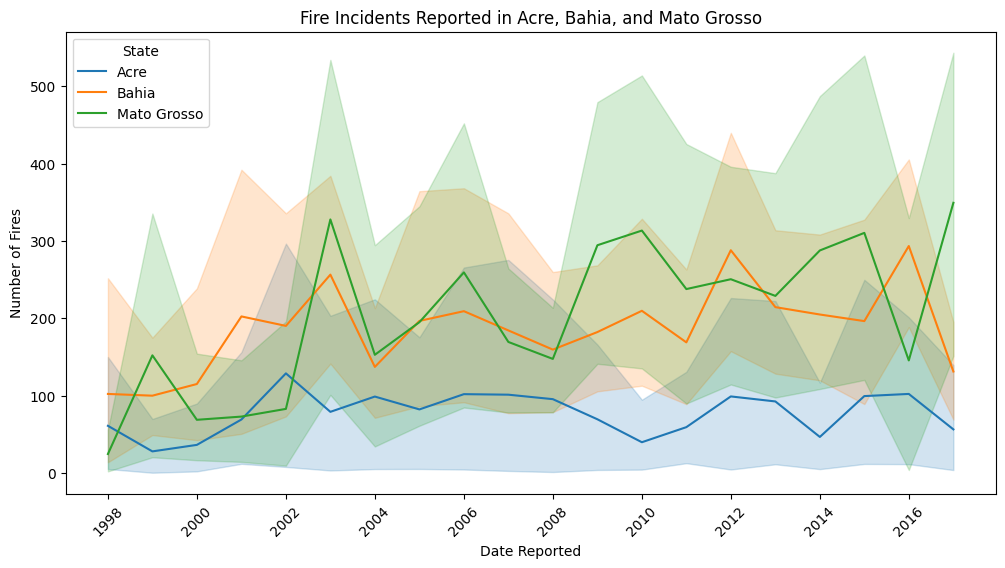

In [9]:
plt.figure(figsize = (12,6))

sns.lineplot(
  data = df_ffire_filt,
  x = 'Date Reported',
  y = 'Number of Fires',
  hue = 'State'
)

plt.title('Fire Incidents Reported in Acre, Bahia, and Mato Grosso')
plt.xlabel('Date Reported')
plt.ylabel('Number of Fires')
plt.legend(title = 'State')

plt.xticks(rotation = 45)

plt.show()

#Activity 3

Create boolean filter for rows with max fires

In [10]:
max_filter = df_ffire['Number of Fires'] == max

Use filter to retrieve record

In [11]:
max_fire = df_ffire[max_filter]
max_fire

,Year,State,Month,Number of Fires,Date Reported
888,2008,Amazonas,September,998.0,2008-01-01


##Answer

Which state has recorded the maximum number of fires on any given day (not the total sum), and in which month did it occur?

In [12]:
state = max_fire['State'].values[0]
month = max_fire['Date Reported'].dt.month.values[0]

print(f'In {month} the state with the maximum number of fires was {state}.')

In 1 the state with the maximum number of fires was Amazonas.


## Activity 4

Calculate total fires for each state and save to DataFrame `df_group_states`

In [20]:
df_group_states = pd.DataFrame(df_ffire.groupby('State')['Number of Fires'].sum())

Print Summary Statistics for `df_group_states`

In [14]:
df_group_states.describe()

,Number of Fires
count,27.000000
mean,25886.076778
std,14260.072004
min,3237.000000
25%,15625.515000
50%,24498.000000
75%,37585.389000
max,51121.198000




What is the minimum and maximum number of total fires records?


In [15]:
max = df_group_states['Number of Fires'].max()
min = df_group_states['Number of Fires'].min()

print(f'Maximum total fires: {max:.0f}.')
print(f'Minimum total fires: {min:.0f}.')

Maximum total fires: 51121.
Minimum total fires: 3237.


Which state has recorded the minimum number of total fires, and which state has recorded the maximum number of total fires?

Use pandas methods `.idxmax()` and `.idxmin()` that return indices corresponding to max/min values

In [16]:
min_state_idx = df_group_states['Number of Fires'].idxmin()
max_state_idx = df_group_states['Number of Fires'].idxmax()

print(f'The State with minimum total fires: {min_state_idx}')
print(f'The State with maximum total fires: {max_state_idx}')

The State with minimum total fires: Sergipe
The State with maximum total fires: São Paulo


##Activity 5



Reset index of `df_group_states`  

Hint: use `.reset_index()`

In [17]:
df_group_states = df_group_states.reset_index()

Arrange DataFrame in descending order by "Number of Fires"


In [21]:
df_group_states = df_group_states.sort_values(by='Number of Fires', ascending=False)

Create `sns.barplot` with Number of Fires on y-axis and State on x-axis, rotate so they are easier to read



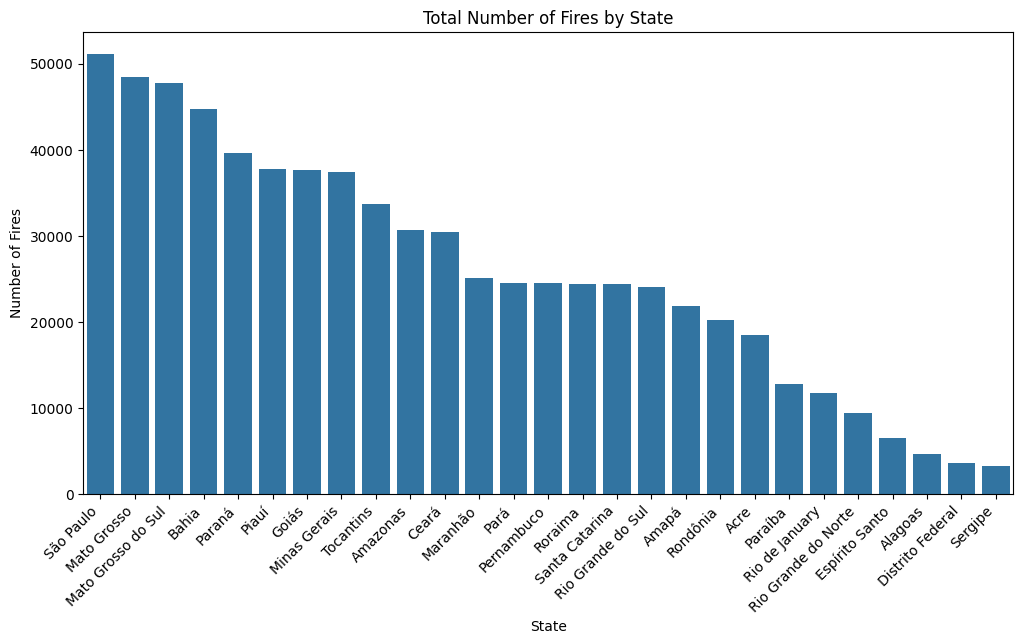

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(data = df_group_states, x = 'State', y = 'Number of Fires')

plt.xticks(rotation=45, ha = 'right')
plt.title('Total Number of Fires by State')

plt.show()